<a href="https://colab.research.google.com/github/hildj/clustering_assignment/blob/main/assignment_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment: $k$ Means Clustering

### `! git clone https://github.com/ds3001f25/clustering_assignment.git`

### **Do two questions in total: "Q1+Q2" or "Q1+Q3"**

**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

In [31]:
!git clone https://github.com/hildj/clustering_assignment/tree/main.git

Cloning into 'main'...
fatal: repository 'https://github.com/hildj/clustering_assignment/tree/main.git/' not found


In [32]:
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

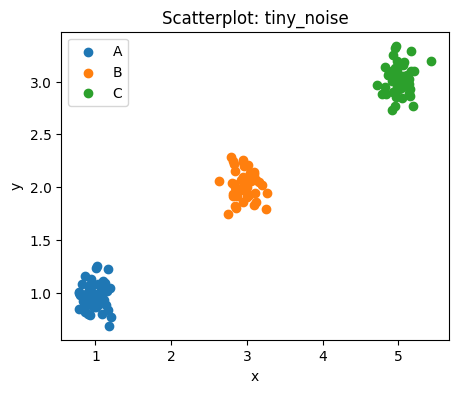

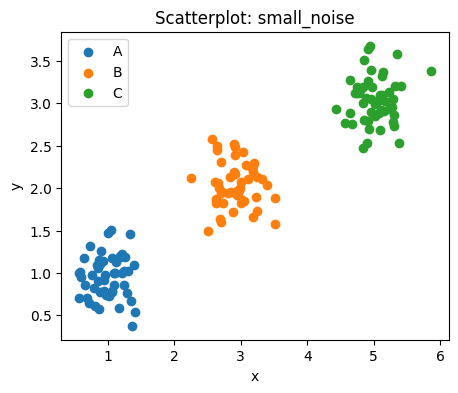

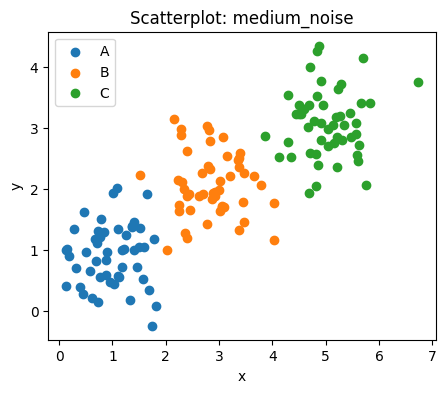

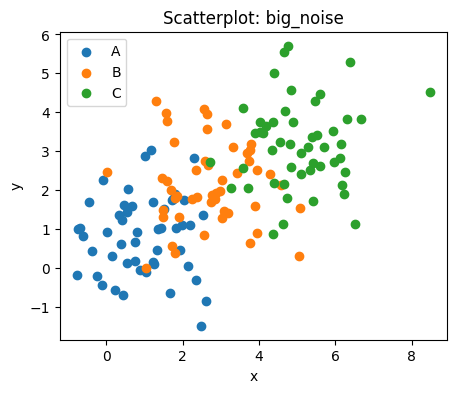

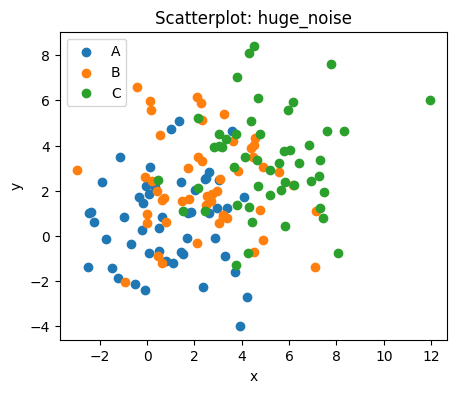

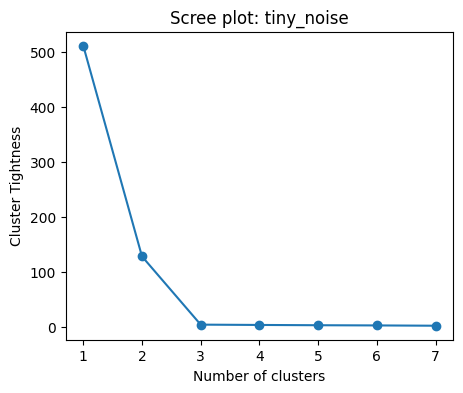

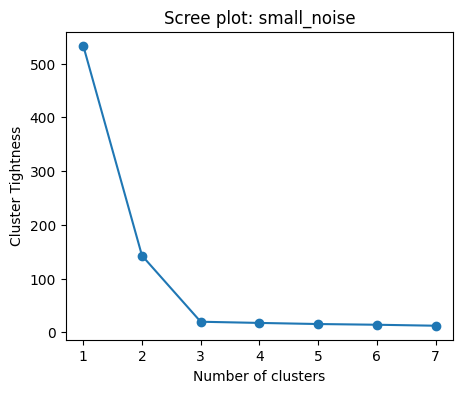

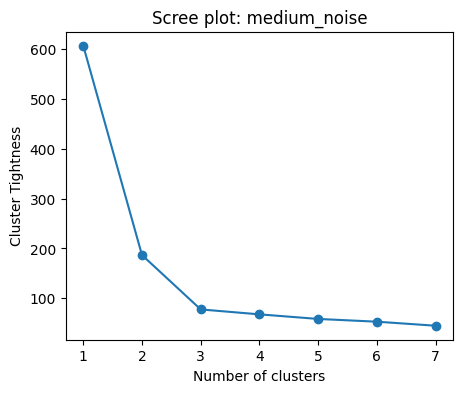

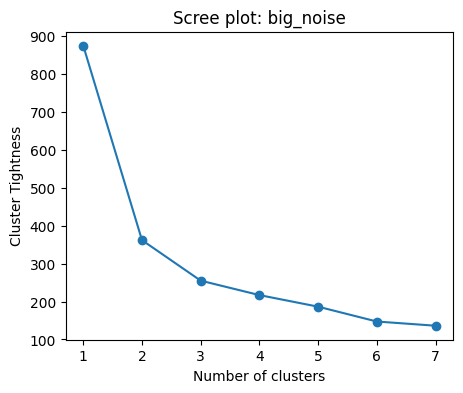

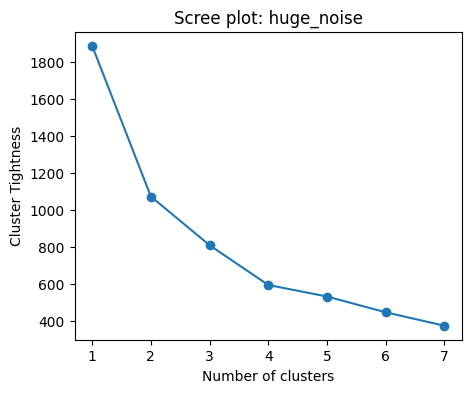

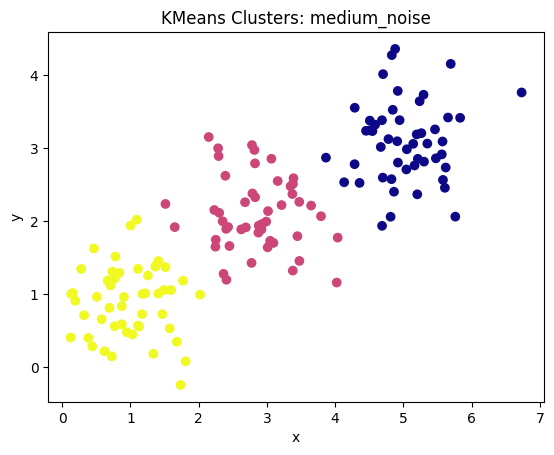

          x                                                              \
      count      mean       std       min       25%       50%       75%   
group                                                                     
0      50.0  5.030588  0.520195  3.865422  4.690328  4.932622  5.338872   
1      50.0  2.851324  0.546509  1.513342  2.404045  2.851953  3.200800   
2      50.0  0.987021  0.488774  0.125117  0.672818  0.975726  1.372792   

                    y                                                    \
            max count      mean       std       min       25%       50%   
group                                                                     
0      6.732614  50.0  3.078162  0.548887  1.933545  2.738681  3.073495   
1      4.037397  50.0  2.089479  0.497845  1.157550  1.750099  1.993689   
2      2.020959  50.0  0.897763  0.480767 -0.243576  0.556126  0.977197   

                           
            75%       max  
group                      
0      3.37945

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def make_clusters(noise_level, n_points=50):
    np.random.seed(100)
    cluster1 = np.array([np.random.normal(1, noise_level, n_points),
                         np.random.normal(1, noise_level, n_points)])
    cluster2 = np.array([np.random.normal(3, noise_level, n_points),
                         np.random.normal(2, noise_level, n_points)])
    cluster3 = np.array([np.random.normal(5, noise_level, n_points),
                         np.random.normal(3, noise_level, n_points)])

    df1 = pd.DataFrame({'x': cluster1[0,:], 'y': cluster1[1,:], 'label':'A'})
    df2 = pd.DataFrame({'x': cluster2[0,:], 'y': cluster2[1,:], 'label':'B'})
    df3 = pd.DataFrame({'x': cluster3[0,:], 'y': cluster3[1,:], 'label':'C'})

    return pd.concat([df1, df2, df3], axis=0)

datasets = {
    'tiny_noise': make_clusters(0.125),
    'small_noise': make_clusters(0.25),
    'medium_noise': make_clusters(0.5),
    'big_noise': make_clusters(1.0),
    'huge_noise': make_clusters(2.0)
}

for name, df in datasets.items():
    plt.figure(figsize=(5,4))
    for label in df['label'].unique():
        subset = df[df['label'] == label]
        plt.scatter(subset['x'], subset['y'], label=label)
    plt.title(f'Scatterplot: {name}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

for name, df in datasets.items():
    coords = df[['x','y']].values
    inertia_list = []
    for k in range(1,8):
        km = KMeans(n_clusters=k, random_state=42).fit(coords)
        inertia_list.append(km.inertia_)

    plt.figure(figsize=(5,4))
    plt.plot(range(1,8), inertia_list, marker='o')
    plt.title(f'Scree plot: {name}')
    plt.xlabel('Number of clusters')
    plt.ylabel('Cluster Tightness')
    plt.show()

medium_coords = datasets['medium_noise'][['x','y']].values
k_med = 3
km_med = KMeans(n_clusters=k_med, random_state=42).fit(medium_coords)
datasets['medium_noise']['group'] = km_med.labels_

plt.scatter(medium_coords[:,0], medium_coords[:,1], c=km_med.labels_, cmap='plasma')
plt.xlabel('x')
plt.ylabel('y')
plt.title('KMeans Clusters: medium_noise')
plt.show()

print(datasets['medium_noise'].groupby('group')[['x','y']].describe())


2. As the noise increases from 0.125 to 2.0, the clusters become less distinct. At low noise (0.125), the points for each group are clearly separated and easy to tell apart. With medium noise (0.5–1.0), the clusters start to overlap a bit, and it’s harder to see the boundaries. At very high noise (2.0), the points are spread out so much that the groups almost blend together, and it’s difficult to visually separate them.
3. As the noise increases, the scree plots change a lot. For the low-noise datasets (0.125 and 0.25), the elbow is very clear around 3 clusters, so it’s easy to pick k. For medium noise (0.5–1.0), the elbow is less sharp, and it’s a bit harder to tell the best k. For the high-noise dataset (2.0), the inertia decreases more gradually, and the elbow is almost gone, making it really hard to choose the right number of clusters. Also, the vertical axis values are higher for higher-noise datasets because the points are more spread out, so the overall cluster tightness is lower.

4. The elbow is the point where adding more clusters doesn’t really improve how tight the clusters are. In this simulation, the inertia drops a lot up to 3 clusters, which matches the 3 groups we created, and then it levels off. Higher noise makes the elbow less obvious, so it’s harder to choose the best number of clusters.

**Q2.** This question is a case study on clustering.

1. Load the `2022 election cycle fundraising.csv` file in the `./data` folder. This has campaign finance data for the 2022 election for House and Senate candidates. We're going to focus on the total amount they raised, `Raised`, the total amount they spent, `Spent`, their available `Cash on Hand`, and their `Debts`. The variables denominated in dollars are messy and require cleaning. How do you handle it?
2. Max-min normalize `Raised` and `Spent`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Raised` against `Spent` and hue the dots by their cluster membership. What do you see? Which politicians comprise the smallest two clusters? If necessary, look up some of these races to see how close they were.
3. Repeat part 2, but for `Cash on Hand` and `Debts`. Compare your results with part 2. Why might this be? If necessary, look up some of these races to see how close they were.
4. Use $k$ means clustering with all four numeric variables. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find useful patterns for you in analyzing the election?

**Q3.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the spending?

In [34]:
!git clone https://github.com/hildj/clustering_assignment/tree/main.git

Cloning into 'main'...
fatal: repository 'https://github.com/hildj/clustering_assignment/tree/main.git/' not found


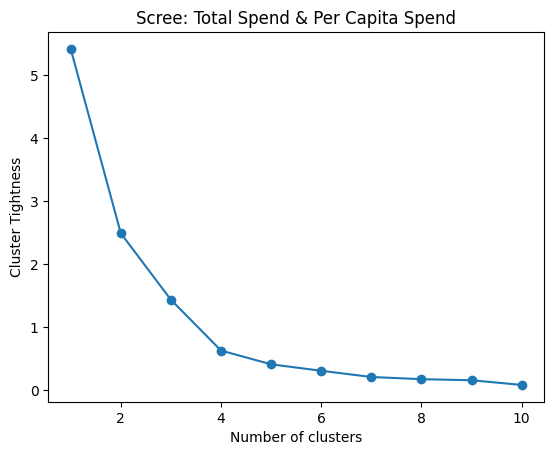

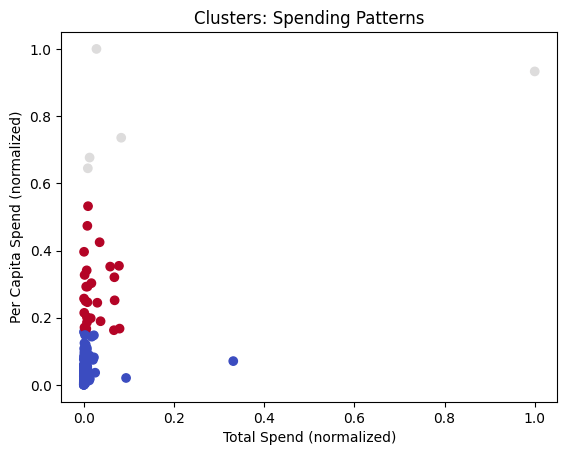

            Spending (2020 USD)                                             \
                          count           mean            std          min   
money_group                                                                  
0                         117.0    4934.990482   24788.961392     8.622460   
1                           5.0  176338.356708  337349.084932  6941.042345   
2                          26.0   18756.499433   21418.276892   405.790494   

                                                                     \
                     25%           50%           75%            max   
money_group                                                           
0             147.873732    483.415023   2567.917819  257973.429834   
1            9978.571429  21816.569767  64558.400000  778397.200000   
2            4141.399749   6330.477850  28516.230742   61712.537169   

            Spending per Capita                                        \
                          count

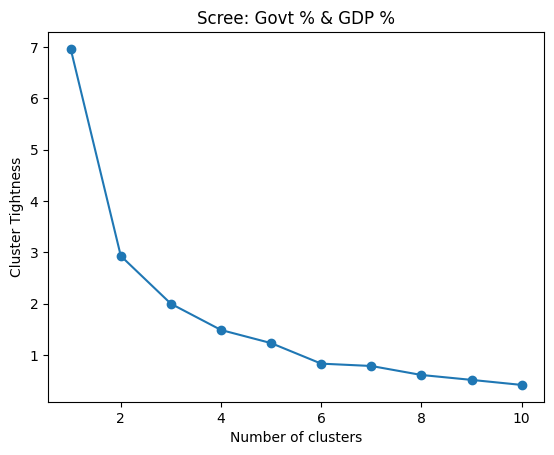

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

mil_data = pd.read_csv('/content/clustering_assignment/data/SIPRI Military Expenditure Database.csv')
mil_2020 = mil_data[mil_data['Year'] == 2020].dropna()
mil_2020 = mil_2020[['Country', 'Spending (2020 USD)', 'Spending per Capita',
                     'Percent of Government Spending', 'Percent of GDP']]

scaler = MinMaxScaler()
money_norm = scaler.fit_transform(mil_2020[['Spending (2020 USD)', 'Spending per Capita']])

money_wcss = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42).fit(money_norm)
    money_wcss.append(km.inertia_)

plt.plot(range(1,11), money_wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Cluster Tightness')
plt.title('Scree: Total Spend & Per Capita Spend')
plt.show()

k_money = 3
km_money = KMeans(n_clusters=k_money, random_state=42).fit(money_norm)
mil_2020['money_group'] = km_money.labels_

plt.scatter(money_norm[:,0], money_norm[:,1], c=km_money.labels_, cmap='coolwarm')
plt.xlabel('Total Spend (normalized)')
plt.ylabel('Per Capita Spend (normalized)')
plt.title('Clusters: Spending Patterns')
plt.show()

print(mil_2020.groupby('money_group')[['Spending (2020 USD)','Spending per Capita']].describe())
print(mil_2020[mil_2020['Country'] == 'United States'])

policy_norm = scaler.fit_transform(mil_2020[['Percent of Government Spending', 'Percent of GDP']])

policy_wcss = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42).fit(policy_norm)
    policy_wcss.append(km.inertia_)

plt.plot(range(1,11), policy_wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Cluster Tightness')
plt.title('Scree: Govt % & GDP %')
plt.show()

k_policy = 3
km_policy = KMeans(n_clusters=k_policy, random_state=42).fit(policy_norm)

1. Based on our output, no further cleaning of the variables was needed. After filtering for 2020 and dropping rows with missing values, all the columns we used (Spending (2020 USD), Spending per Capita, Percent of Government Spending, and Percent of GDP) were numeric and ready for normalization and clustering.

2. After normalizing Spending (2020 USD) and Spending per Capita and running KMeans, the scree plot showed a clear elbow around 3 clusters. The scatter plot shows that most countries are in the low-spending cluster, a smaller group is in the medium-spending cluster, and a few high-spending countries form the top cluster. The U.S. is in the high-spending cluster for both total and per-capita spending. Overall, the clusters show a clear separation between countries with very high military budgets, medium budgets, and very low budgets, and the points spread out more as spending decreases.

3. When I clustered using `Percent of Government Spending` and `Percent of GDP`, the groups looked different from the total and per-capita spending clusters. Some countries with low total spending ended up in higher clusters because they spend a large share of their government budget or GDP on the military. This shows that relative spending can highlight different patterns than absolute spending—small countries can appear “big spenders” in relative terms even if their total budget is small.

4. Using all four variables together, the clusters balance both absolute and relative spending. The U.S. is still in the high-spending group, but some smaller countries shift clusters based on how much of their budget or GDP they spend. This gives a more complete picture than just total/per-capita or percent-of-budget alone.

5. Yes, the KMeans algorithm revealed patterns in military spending. It clearly separates high-, medium-, and low-spending countries and shows that countries can be “big spenders” either in absolute terms or relative to their budget/GDP, which isn’t obvious just by looking at one variable.